# Theory

**Reinforcement Learning** - uses training information that evaluates the actions taken rather than instructs by giving correct actions.

---

**Evaluative Feedback (associative)**

Indicates how good the action taken was, but not whether it was the best of the worst action possible

**Instructive Feedback (nonassociative)**

Indicates correct action to take, independently of the action actually taken, which is basically supervised learning.

---

The main difference is that Evaluative Feedback 'chains' action and result, whereas Instructive Feedback thinks in a way of separate events in time.

Evaluative Feedback is the core of Reinforcement Learning. Even though RL methods are way more complicated than just Evaluative Feedback, it remains the corner stone of Reinforcement Learning.

# 2.1 k-armed Bandit Problem

## Problem

1. Repeatedly choose among $k$ different options (actions)
2. After each choice we recieve reward (picked from stationary probability dist. that depends on action we select)
3. Objective is to maximize the expected total reward over some time period `time_steps`

## Vocab

* $q_*(a)$ - value of action, which is expected or mean reward each of the $k$ actions given the action $A_t$ is selected
* $A_t$ - action selected in time $t$
* $R_t$ - corresponding reward in time $t$
* $Q_t(a)$ - estimated value of action $a$ at time step $t$
* greedy action - if we maintain estimates of the action values, then at any time step there is at least one action whose estimated value is greatest we call it greedy actions
* exploitation - when we select one of greedy actions, best to do in a single step
* exploration - when we select nongreedy action, may produce greater total reward in the long run

## Math

The value $q_*(a)$ is the expected reward given that $a$ is selected

$$ q_*(a) \doteq \mathbb{E} \Big[R_t | A_t = a\Big] $$

## Assumptions

* We don't know value of each action
* We don't know the action values with certainty, although we may have estimates
* If we maintain estimates of the action values, then at any time step there is at least one action whose estimated value is greatest we call it greedy actions

## Goal

* Approximate true action values $q_*(a)$
* Maximize total reward

At this stage we do not use $
Q
t(a)$
	​ nor attempt to approximate
$
q_
∗
(a)$. Actions are selected uniformly at random, representing pure exploration.

## Code

We first test pure exploitation and pure exploration. At this stage, we do not introduce any mechanism to balance exploration and exploitation. Instead, we run two separate loops: one using exploration only, and one using exploitation only.

### Exploration

In exploration we pick always random action, we explore. We're going to use uniform distribution over all actions.

In [ ]:
import numpy as np
from collections import defaultdict

action_space            = 10                             # number of actions
time_steps              = 1000                           # number of time steps
actions                 = np.arange(action_space)        # available actions
all_rewards             = defaultdict(list)              # rewards collected per action
action_counts           = defaultdict(int)               # how many times each action was chosen
total_rewards_over_time = []                             # reward at each time step
q_star                  = np.random.randn(action_space)  # pick random rewards before loop to simulate some fixed rewards distribution

for t in range(time_steps):
    # sample action uniformly at random
    a_t = np.random.choice(actions).item()

    # sample reward
    r_t = q_star[a_t] + np.random.randn()  # actions reward from q_star AND ADD some uncertainty (noise) from normal distribution

    # update action count
    action_counts[a_t] += 1

    # store reward for given action
    all_rewards[a_t].append(r_t)

    # log reward over time
    total_rewards_over_time.append(r_t)

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

def plot_results(total_rewards_over_time, all_rewards, action_counts, actions, title):
    actions_sorted = sorted(actions)

    mean_rewards = np.array([
    np.mean(all_rewards[a]) if len(all_rewards[a]) > 0 else 0.0
    for a in actions_sorted
])

    counts = np.array([action_counts[a] for a in actions_sorted])

    norm = plt.Normalize(vmin=-2, vmax=2)    # we setup global vmax and vmin for gaussian norm
    colors = plt.cm.Reds(norm(mean_rewards))

    fig = plt.figure(figsize=(15, 4))

    # Total reward over time
    ax1 = plt.subplot(1, 3, 1)
    ax1.plot(total_rewards_over_time)
    ax1.set_xlabel("Time step")
    ax1.set_ylabel("Reward")
    ax1.set_title("Reward over time")

    # Counts + mean reward as color
    ax2 = plt.subplot(1, 3, 2)
    bars = ax2.bar(actions_sorted, counts, color=colors)
    ax2.set_xlabel("Action")
    ax2.set_ylabel("Number of selections")
    ax2.set_title("Action counts (color = mean reward)")
    ax2.set_xticks(actions)

    sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax2, label="Mean reward")

    total_reward = np.sum(total_rewards_over_time)

    fig.canvas.draw()

    bbox1 = ax1.get_position()
    bbox2 = ax2.get_position()
    x_center = (bbox1.x0 + bbox2.x1) / 2

    # push subplots a bit down to create space
    fig.subplots_adjust(top=0.80)

    fig.text(
        x_center, 0.97,
        f"{title} — Total reward = {total_reward:.2f}",
        ha="center",
        va="top",
        fontsize=14
    )

    plt.show()

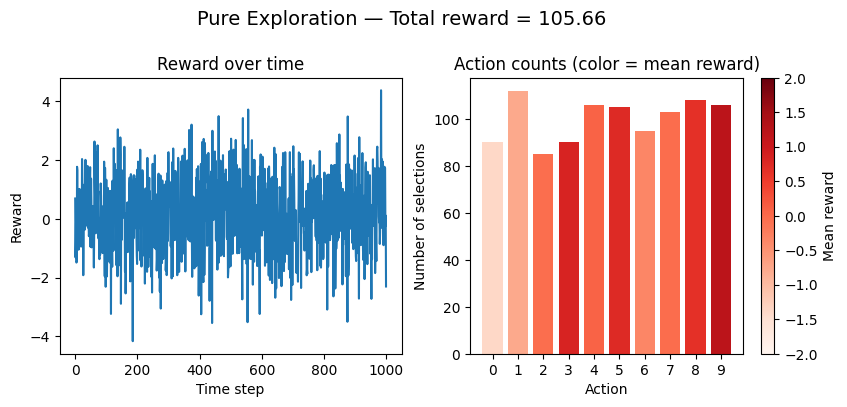

In [ ]:
plot_results(total_rewards_over_time, all_rewards, action_counts, actions, 'Pure Exploration')

Our actions are completely random. We can see that the occurrence of picking an action is not dependent on the mean reward of the given action. Ideally we'd like to see higher bars with darker red.

### Exploitation

Now we only exploit, i.e. always we pick action with highest historical mean reward - without 1st action since we need to have some history. Mean reward is discussed in Action-value method but we will implement it here already to get the idea how exploitation works.

In [ ]:
import numpy as np
from collections import defaultdict

action_space            = 10                             # number of actions
time_steps              = 1000                           # number of time steps
actions                 = np.arange(action_space)        # available actions
all_rewards             = defaultdict(list)              # rewards collected per action
action_counts           = defaultdict(int)               # how many times each action was chosen
total_rewards_over_time = []                             # reward at each time step
mean_rewards            = {a: 0.0 for a in actions}      # store reward mean of each action
q_star                  = np.random.randn(action_space)  # pick random rewards before loop to simulate some fixed rewards distribution

for t in range(time_steps):
    # for first t pick random action - no re
    if t == 0:
        a_t = np.random.choice(actions).item()
    else:
        a_t = max(actions, key=lambda a: mean_rewards[a])

    # sample reward
    r_t = q_star[a_t] + np.random.randn()  # actions reward from q_star AND ADD some uncertainty (noise)

    # update action count
    action_counts[a_t] += 1

    # store reward for given action
    all_rewards[a_t].append(r_t)

    # update mean rewards
    n = action_counts[a_t]
    mean_rewards[a_t] += (r_t - mean_rewards[a_t]) / n  # explained in incremental implementation

    # log reward over time
    total_rewards_over_time.append(r_t)

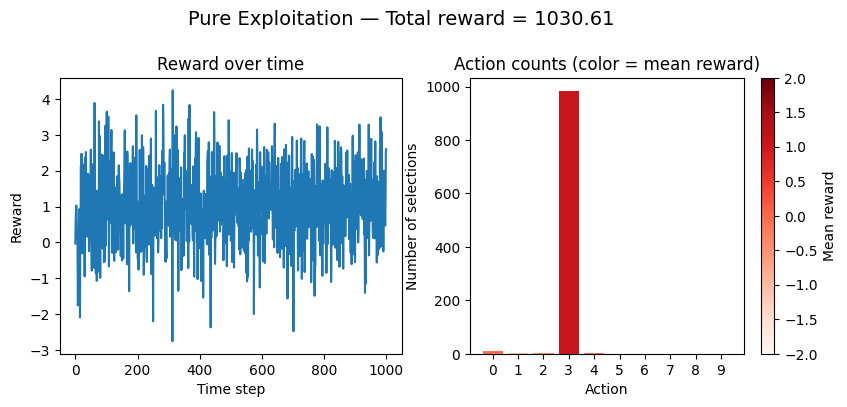

In [ ]:
plot_results(total_rewards_over_time, all_rewards, action_counts, actions, 'Pure Exploitation')

In only exploitation setup we will most likely pick the first action. If the first action gives a positive reward, it will be selected as long as its mean reward stays above zero. This is exactly what it means to not explore — we stick to what is already known, even though some exploration could lead to higher reward.

# 2.2 Action-value Methods

## Goal

Now, let's consider how to estimate values of actions to make decisions on actions.

## Problem

* Find mean of all historical rewards of given action $a_t$

## Vocab

* action-value mehods - methods for estimating the values of actions and for using the estimates to make action selection decisions
* sample-average - method for estimating action values
* $\epsilon$ - probability of picking random action instead of optimal, i.e. $1-\epsilon$ is the probability of picking greedy action

## Math

$$ A_t \doteq = \underset{a}{arg\,max}\;Q_t(a)$$

We pick actions with the highest estimated value, that is, one of the greedy actions as defined

## Code

In [ ]:
import numpy as np
from collections import defaultdict

action_space            = 10                             # number of actions
time_steps              = 1000                           # number of time steps
actions                 = np.arange(action_space)        # available actions
all_rewards             = defaultdict(list)              # rewards collected per action
action_counts           = defaultdict(int)               # how many times each action was chosen
total_rewards_over_time = []                             # reward at each time step
mean_rewards            = {a: 0.0 for a in actions}      # store reward mean of each action
q_star                  = np.random.randn(action_space)  # pick random rewards before loop to simulate stationarity
eps                     = 0.5                            # probability of nongreedy action

for t in range(time_steps):
    # for first t pick random action - no re
    if t == 0 or np.random.random() < eps:
        a_t = np.random.choice(actions).item()
    else:
        a_t = max(actions, key=lambda a: mean_rewards[a])

    # sample reward
    r_t = q_star[a_t] + np.random.randn()  # actions reward from q_star AND ADD some uncertainty (noise)

    # update action count
    action_counts[a_t] += 1

    # store reward for given action
    all_rewards[a_t].append(r_t)

    # update mean rewards
    n = action_counts[a_t]
    mean_rewards[a_t] += (r_t - mean_rewards[a_t]) / n  # explained in action-value methods

    # log reward over time
    total_rewards_over_time.append(r_t)

<>:1: SyntaxWarning: invalid escape sequence '\e'
<>:1: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-608607280.py:1: SyntaxWarning: invalid escape sequence '\e'
  plot_results(total_rewards_over_time, all_rewards, action_counts, actions, f'$\epsilon = {eps}$')


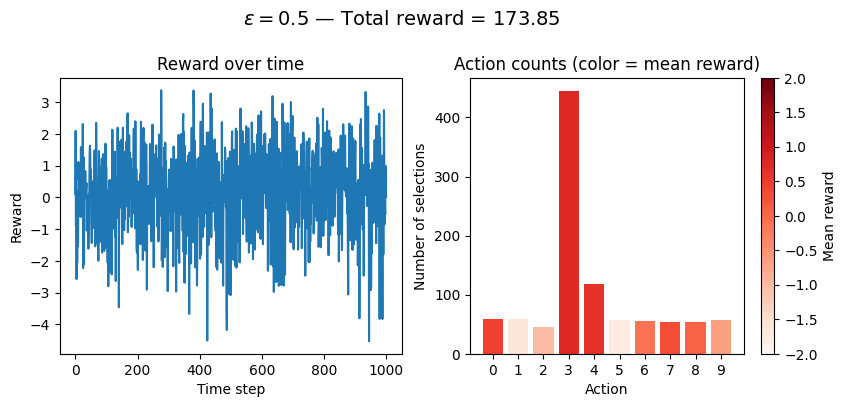

In [ ]:
plot_results(total_rewards_over_time, all_rewards, action_counts, actions, f'$\epsilon = {eps}$')

# 2.3 The 10-armed Testbed

## Goal

Let's conduct an experiment of different $\epsilon$ on 2000 randomly generated $k$-armed bandit problems with $k=10$.

## Code

In [ ]:
import numpy as np
from collections import defaultdict

def single_bandit(epsilon, q_star, time_steps=10000):
    '''
    epsilon - probability of nongreedy action
    q_start - rewards for each action, fixed for whole single_bandit run in all time_steps
    time_steps - count of iteration within single_bandit run
    '''
    actions = np.arange(len(q_star))                                            # define all actions

    action_counts = defaultdict(int)                                            # action counts
    mean_rewards = {a: 0.0 for a in actions}

    rewards_over_time = []                                                      # rewards register
    optimal_action_over_time = []                                               # to see if we picked optimal action

    optimal_action = np.argmax(q_star)                                          # best action from q_star

    for t in range(time_steps):
        if np.random.rand() < epsilon:
            a_t = np.random.choice(actions)
        else:
            a_t = max(actions, key=lambda a: mean_rewards[a])

        reward = q_star[a_t] + np.random.randn()

        action_counts[a_t] += 1
        n = action_counts[a_t]
        mean_rewards[a_t] += (reward - mean_rewards[a_t]) / n

        rewards_over_time.append(reward)
        optimal_action_over_time.append(a_t == optimal_action)

    return np.array(rewards_over_time), np.array(optimal_action_over_time)

In [ ]:
def run_experiment(epsilons, n_runs=2000, time_steps=10000, n_actions=10):
    results = {}

    for epsilon in epsilons:
        avg_rewards = np.zeros(time_steps)
        optimal_action_rate = np.zeros(time_steps)

        for run in range(1, n_runs + 1):
            q_star = np.random.randn(n_actions)                                 # initiate q_star before single_bandit to maintain some hidden reward distribution

            rewards, optimal = single_bandit(epsilon, q_star, time_steps)

            avg_rewards += rewards
            optimal_action_rate += optimal

        avg_rewards /= n_runs
        optimal_action_rate = 100 * optimal_action_rate / n_runs

        print(
            f"[ε={epsilon:.2f}] done | "
            f"avg total reward = {avg_rewards.sum():.2f} | "
            f"% optimal action (final step) = {optimal_action_rate[-1]:.2f}%"
        )

        results[epsilon] = {
            "avg_rewards": avg_rewards,
            "optimal_action_rate": optimal_action_rate
        }

    return results


In [ ]:
epsilons = np.concatenate(([0.01], np.linspace(0, 1, 11)))
epsilons

array([0.01, 0.  , 0.1 , 0.2 , 0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 ,
       1.  ])

In [ ]:
epsilons = np.concatenate(([0.01], np.linspace(0, 1, 11)))

results = run_experiment(
    epsilons=epsilons,
    n_runs=2000,
    time_steps=10000
)

[ε=0.01] done | avg total reward = 14314.11 | % optimal action (final step) = 88.10%
[ε=0.00] done | avg total reward = 10263.88 | % optimal action (final step) = 34.70%
[ε=0.10] done | avg total reward = 13724.43 | % optimal action (final step) = 87.50%
[ε=0.20] done | avg total reward = 12032.54 | % optimal action (final step) = 80.40%
[ε=0.30] done | avg total reward = 10671.10 | % optimal action (final step) = 72.45%
[ε=0.40] done | avg total reward = 9249.93 | % optimal action (final step) = 62.45%
[ε=0.50] done | avg total reward = 7389.87 | % optimal action (final step) = 55.20%
[ε=0.60] done | avg total reward = 6207.85 | % optimal action (final step) = 43.85%
[ε=0.70] done | avg total reward = 4600.74 | % optimal action (final step) = 35.15%
[ε=0.80] done | avg total reward = 2912.14 | % optimal action (final step) = 27.60%
[ε=0.90] done | avg total reward = 1522.51 | % optimal action (final step) = 19.60%
[ε=1.00] done | avg total reward = -107.16 | % optimal action (final st

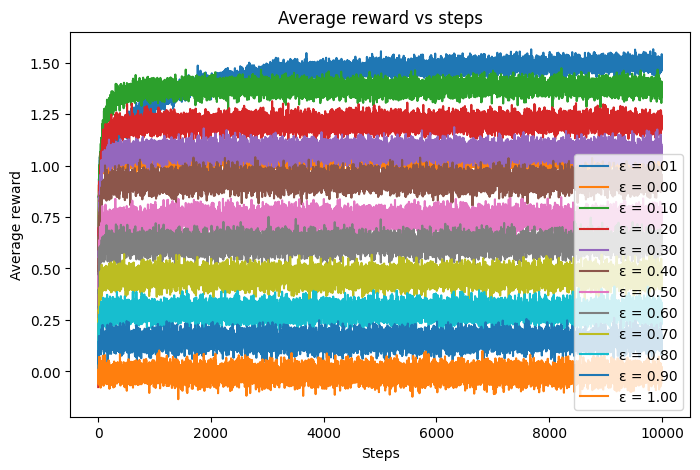

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for epsilon, data in results.items():
    plt.plot(data["avg_rewards"], label=f"ε = {epsilon:.2f}")

plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title("Average reward vs steps")
plt.legend()
plt.show()


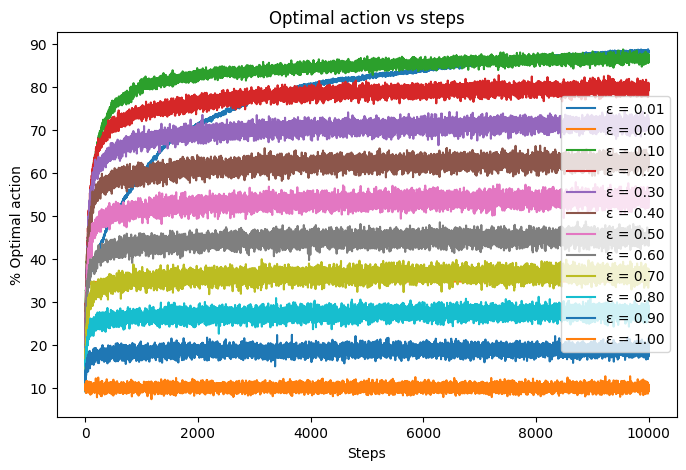

In [ ]:
plt.figure(figsize=(8, 5))

for epsilon, data in results.items():
    plt.plot(data["optimal_action_rate"], label=f"ε = {epsilon:.2f}")

plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.title("Optimal action vs steps")
plt.legend()
plt.show()


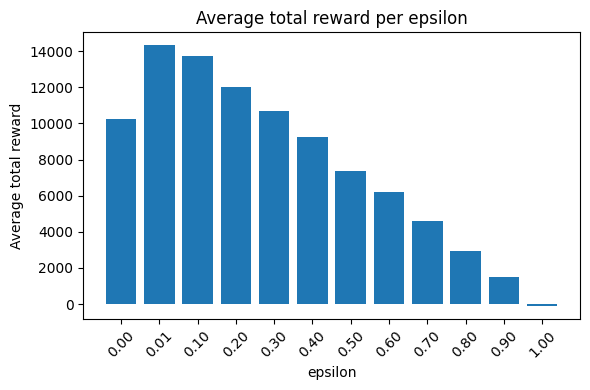

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ensure consistent order
epsilons_sorted = sorted(results.keys())

avg_total_rewards = [
    results[eps]["avg_rewards"].sum()
    for eps in epsilons_sorted
]

plt.figure(figsize=(6, 4))
plt.bar(range(len(epsilons_sorted)), avg_total_rewards)

plt.xticks(
    range(len(epsilons_sorted)),
    [f"{eps:.2f}" for eps in epsilons_sorted],
    rotation=45
)

plt.xlabel("epsilon")
plt.ylabel("Average total reward")
plt.title("Average total reward per epsilon")
plt.tight_layout()
plt.show()

After tests we can see that $\epsilon=0.1$ performs the best in the short-run, it converges fastest. However, $\epsilon = 0.01$ has higher ceil in a long-run outperforming all other $\epsilon$ values.

# 2.4 Incremental Implementation

## Goal

* Compute in a computationally efficient manner, in particular, with constant memory and constant per-time-step computation.

## Math

$$ Q_t(a) \doteq \frac{\text{sum of rewards when} \;a\; \text{taken prior to t}}{\text{number of times}\;a\;\text{taken prior to t}} = \frac{\sum_{i=1}^{t-1}R_i\cdot\mathbb{1}_{A_i = a}}{\sum_{i=1}^{t-1}\mathbb{1}_{A_i=a}} $$

where $\mathbb{1_{predicate}}$ denotes the random variable that is 1 if predicate is true and 0 if it is not. It's just to prevent division by 0:



```
if action_count[a] == 0:
  Q[a] = 0
else:
  Q[a] = sum_rewards[a] / action_count[a]
```



This formula is what we call *sample-average*

Let's dismantle that

mean after $n$ samples:

$$ Q_n = \frac{1}{n} \sum_{i=1}^n R_i \rightarrow \sum_{i=1}^nR_i = nQ_n$$

mean after $n+1$ samples:

$$ Q_{n+1} = \frac{1}{n+1}\Big(\sum_{i=1}^n R_i + R_{n+1}\Big) \rightarrow Q_{n+1} = \frac{1}{n+1}\Big(nQ_n + R_{n+1}\Big)$$

and cleaning:

$$ Q_{n+1} = \frac{n}{n+1}Q_n + \frac{1}{n+1}R_{n+1} $$

We know that:

$$ \frac{n}{n+1} = \frac{n+1}{n+1} - \frac{1}{n+1}=1 - \frac{1}{n+1} $$

so:

$$ Q_{n+1} = \Big(1 - \frac{1}{n+1}\Big)\,Q_n + \frac{1}{n+1}R_{n+1}$$

multiply $Q_n$:
$$ Q_{n+1} = Q_n - \frac{1}{n+1}Q_n + \frac{1}{n+1}R_{n+1} $$

and finally:
$$ Q_{n+1} = Q_n + \frac{1}{n+1}(R_{n+1}-Q_n) $$

## Code

We already implemented means update in previous sections, as a recap this lines of code express above formula:



```
  action_counts[a_t]       += 1
  reward                    = q_star[a_t] + np.random.randn()
  action_reward_means[a_t] += (reward - action_reward_means[a_t]) / action_counts[a_t]
```



Let's note that first we update `action_counts[a_t]` so now it express $n+1$ action count. We do the same for `reward` which before update becomes $n+1$ reward, i.e. of current time step. Only then we update `action_reward_means` where of course right side of `action_reward_means[a_t]` store mean reward for time step $n$.

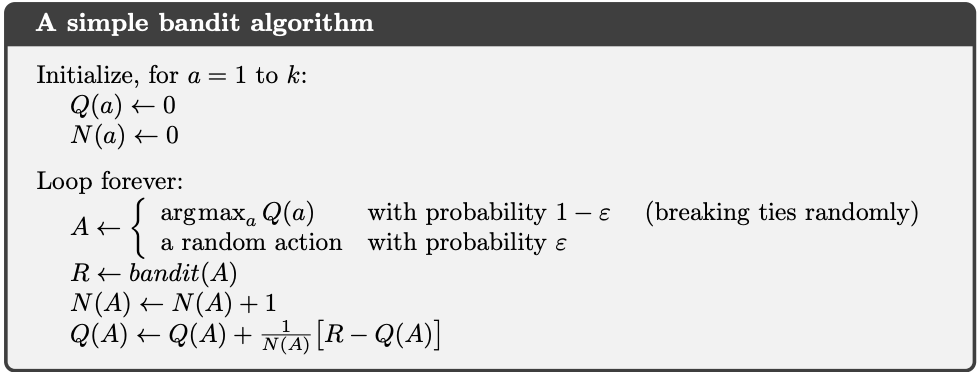

Above we have proposed algorithm from the book, and below it's implementation.

In [ ]:
import numpy as np

def single_bandit(actions, q_star, epsilon, time_steps):
  # N(a)
  action_counts       = {a:0 for a in actions}
  # Q(a)
  action_reward_means = {a:0 for a in actions}

  # Loop Over
  for t in range(time_steps):
    # A
    # argmax_a Q(a) with probability 1-epsilon (breaking ties randomly)
    if np.random.rand() < 1 - epsilon:
      best = max(action_reward_means.values())
      candidates = [a for a, v in action_reward_means.items() if v == best]     # if tie more than 1 v is equal to best
      a_t = np.random.choice(candidates)
    # a ranom action with probability epsilon
    else:
      a_t = np.random.choice(actions)

    # R <- badit(A)
    reward                    = q_star[a_t] + np.random.randn()                 # we add random noise since this is an experiment and we actually know true distribution of rewards, with that knowledge and without noise it would be trivial
    # N(A) <- N(A) + 1
    action_counts[a_t]       += 1
    # Q(A) <- Q(A) + (R - Q(A) / N(A))
    action_reward_means[a_t] += (reward - action_reward_means[a_t]) / action_counts[a_t]

  return action_counts, action_reward_means

In [ ]:
n_actions  = 5
actions    = np.arange(n_actions)
q_star     = np.random.randn(n_actions)
epsilon    = 0.1
time_steps = 1000

action_counts, action_reward_means = single_bandit(actions, q_star, epsilon, time_steps)

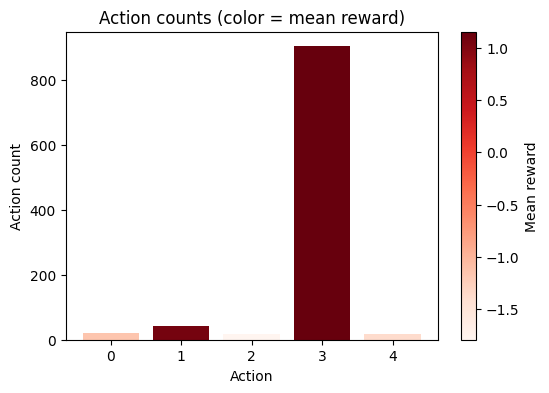

In [ ]:
actions = list(action_counts.keys())
counts  = [action_counts[a] for a in actions]
means   = [action_reward_means[a] for a in actions]

fig, ax = plt.subplots(figsize=(6,4))

ax.bar(actions, counts)
ax.set_xlabel('Action')
ax.set_ylabel('Action count')
ax.set_title('Action counts (color = mean reward)')

sm = plt.cm.ScalarMappable(norm=norm, cmap='Reds')
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Mean reward')

plt.show()

# 2.5 Tracking a Nonstationary Problem

## Vocab

Stationary problem – rewards distribution does not change over time, i.e. `q_star` is fixed throughout the whole training.

Nonstationary problem – rewards distribution changes over time, i.e. `q_star` is updated during training (e.g. random walk).

## Goal

In Nonstationary Problem it make sense to give more weight to recent rewards than long-past rewards. One way of doing this is to use a constant step-siez parameter.

## Problem

In the Incremental Implementation section, the action-value estimate is a simple mean:

$$ Q_{n+1} = Q_n + \frac{1}{n+1}(R_{n+1}-Q_n) $$

This is useful in the stationary `q_star` setting, i.e., when rewards are fixed during training. However, in the real world, rewards change, or at least are not known in advance. We want them to behave like a system that leads our agent toward a given goal, rather than a fixed storage of rewards.

In a nonstationary problem, we update the action-value estimate $Q_{n+1}$ with

$$ Q_{n+1} \doteq Q_n + \alpha(R_n-Q_n) $$

We could still use the mean for the action-value estimate, but we would dilute important information. Let us note that the only difference is here:

The stationary problem uses $\frac{1}{n+1}$.

The nonstationary problem uses $\alpha$.

$\frac{1}{n+1}$ converges to 0, while $\alpha$ always stays the same. We'll see that mechanism of $\alpha$ promotes new rewards more. When using the mean, updates to $Q_n$ become less and less important over time. This is important for nonstationary systems, because we can run problems for many iterations with a changing optimal action, which requires fixed updates.


## Math

In incremental update rule for updating an average $Q_n$ of the $n-1$ past rewards is modified to be:

$$ Q_{n+1} \doteq Q_n + \alpha\Big[R_n-Q_n\Big] $$

where the step-size parameter $\alpha \in (0,1]$ is constant. This results in $Q_{n+1}$ being weighted average of past rewards and the initial estimate $Q_1$:

$$
\begin{aligned}
Q_{n+1} &= Q_n + \alpha (R_n - Q_n) \\
        &= \alpha R_n + (1-\alpha) Q_n \\
        &= \alpha R_n + (1-\alpha)\bigl[\alpha R_{n-1} + (1-\alpha) Q_{n-1}\bigr] \\
        &= \alpha R_n + (1-\alpha)\alpha R_{n-1} + (1-\alpha)^2 \alpha R_{n-2} + \dots \\
        &\quad + (1-\alpha)^{n-1}\alpha R_1 + (1-\alpha)^n Q_1 \\
        &= (1-\alpha)^n Q_1 + \sum_{i=1}^n \alpha (1-\alpha)^{n-i} R_i
\end{aligned}
$$


**Exponential-recency-weighted average**

Sum of weights $(1-\alpha)^n + \sum_{i=1}^n \alpha(1-\alpha)^{n-i}=1$

In [ ]:
for i in range(5):
  alpha = np.random.rand()
  n     = 1000
  print('alpha:', alpha)

  right = 0
  for i in range(1, n+1):
    right += alpha*(1-alpha)**(n-i)

  left = (1-alpha)**n

  result = left + right
  print('Should equal 1 -> result =', result, '\n')

alpha: 0.5385552187309419
Should equal 1 -> result = 1.0 

alpha: 0.31414678056930745
Should equal 1 -> result = 1.0 

alpha: 0.3778505378156337
Should equal 1 -> result = 1.0 

alpha: 0.6595271023091829
Should equal 1 -> result = 1.0 

alpha: 0.3214187965779155
Should equal 1 -> result = 1.0 



$\alpha(1-\alpha)^{n-i}$ depends on how many rewards ago, $n-i$, it was observed. $n$ is the number of time steps, while for the 1st reward $n-i$ is the largest. The base of the power is $1-\alpha$, and since $\alpha > 0$, we have $1-\alpha < 1$, meaning we have an inverse power: the larger the power, the smaller the result. Older rewards update $Q$ with smaller impact, and the current reward updates the current $Q$ with the largest impact, because then $i = n$ $\rightarrow$ $n-n=0$ and $(1-\alpha)^0=1$. This is called an exponential-recency-weighted average.

**Stochastic Approximation Theory**

Stochastic approximation theory tells us when algorithms that learn from noise will converge, even though:

* observations are random
* updates are approximations
* we don't know the real function

Convergence with probability 1 means that the algorithm almost certainly will converge to the true value (excluding events with probability 0).

Now, when our action’s reward weight is $\alpha_n(a) = \frac{1}{n}$, as in the sample-average case in stationary $q_*$, due to stochastic approximation theory the conditions required to assure convergence with probability 1 are:

$$ \sum_{n-1}^{\infty} \alpha_n(a) = \infty\;\;\;\text{    and  }\;\;\; \sum_{n-1}^{\infty} \alpha_n^2(a) \leq \infty $$

Those two conditions are met for $\alpha_n(a) = \frac{1}{n}$. However, **we don’t want** that in nonstationary problems. Converging means that we assume there is one single action which is correct, and that is not true. It is like saying that turning left on the road is always optimal. We want the model to adapt, i.e., not to converge. $\alpha_n(a) = \alpha$ does not meet those requirements, meaning the model will not converge and will keep being uncertain about what the best action at a given moment actually is.

## Code

In [ ]:
import numpy as np

def single_bandit(actions, q_star, epsilon, alpha, time_steps):

  action_counts          = {a:0 for a in actions}
  action_value_estimates = {a:0 for a in actions}

  rewards_history        = np.zeros(time_steps)
  optimal_action_history = np.zeros(time_steps)

  for t in range(time_steps):

    q_star        += np.random.normal(0, 0.01, size = len(actions))             # random walk
    optimal_action = np.argmax(q_star)                                          # optimal action can change, i.e. we put it inside the loop

    if np.random.rand() <= epsilon:
      a_t = np.random.choice(actions)
    else:
      best = max(action_value_estimates.values())
      choices = [a for a, v in action_value_estimates.items() if v == best]
      a_t = np.random.choice(choices)

    action_counts[a_t]           += 1
    reward                        = q_star[a_t] + np.random.randn()
    action_value_estimates[a_t]  += (reward - action_value_estimates[a_t]) * alpha # we multiply by alpha

    rewards_history[t]        = reward
    optimal_action_history[t] = a_t == optimal_action

  return rewards_history, optimal_action_history

## Experiment

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_actions  = 10
actions    = np.arange(n_actions)
epsilon    = 0.01
time_steps = 10000

alphas = np.linspace(0.01, 1.0, 11)

all_rewards = {}
all_optimal = {}

$\alpha$ experiment

In [ ]:
for alpha in alphas:
    q_star = np.random.randn(n_actions)  # fresh environment per alpha

    rewards_history, optimal_action_history = single_bandit(
        actions, q_star, epsilon, alpha, time_steps
    )

    all_rewards[alpha] = np.cumsum(rewards_history) / (np.arange(time_steps) + 1)
    all_optimal[alpha] = np.cumsum(optimal_action_history) / (np.arange(time_steps) + 1)


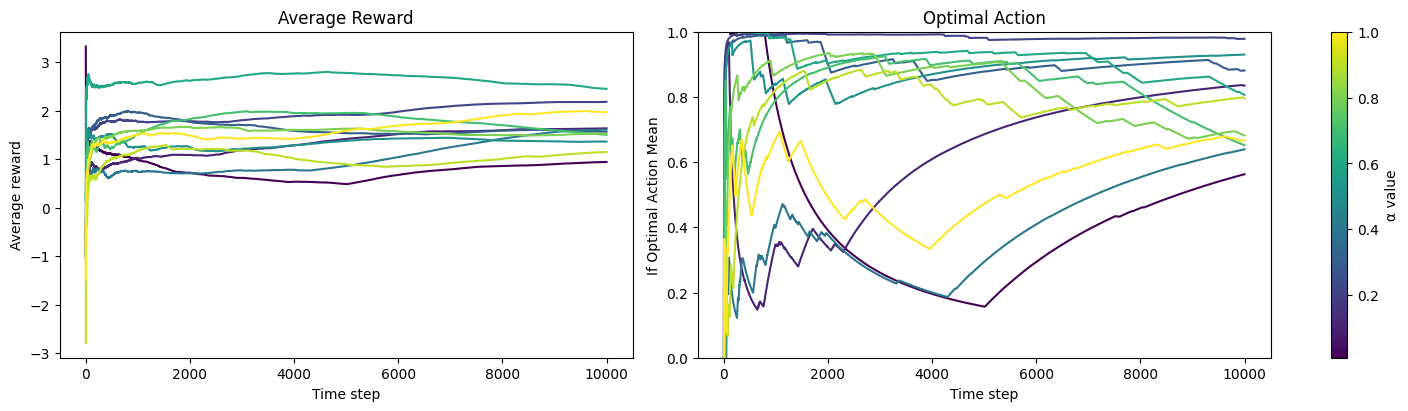

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# figure with proper layout
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

# colormap setup
alphas = np.array(list(all_rewards.keys()))
norm = mcolors.Normalize(vmin=alphas.min(), vmax=alphas.max())
cmap = cm.viridis

# Average Reward
for alpha, avg_reward in all_rewards.items():
    axes[0].plot(avg_reward, color=cmap(norm(alpha)))

axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Average reward")
axes[0].set_title("Average Reward")

# Optimal Action Mean
for alpha, opt_mean in all_optimal.items():
    axes[1].plot(opt_mean, color=cmap(norm(alpha)))

axes[1].set_xlabel("Time step")
axes[1].set_ylabel("If Optimal Action Mean")
axes[1].set_title("Optimal Action")
axes[1].set_ylim(0, 1)

# colorbar as legend
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, orientation='vertical')
cbar.set_label("α value")

plt.show()


In general small $\alpha \in (0.05, 0.2)$ changes each $Q$ just a little bit, ranking of actions is stable, when optimal action changes agent switches more slowly.

Big $\alpha \in (0.5, 1.0)$ updates Q strongly, when we hit correct action our reward jumps high and avg reward increases, we get high mean reward.

# 2.6 Optimistic Initial Values

## Problem

Using initial $Q$ we’re always biased to some extent. What is proposed here is the initial distribution of $Q$, where instead of all random $Q$ or all zero $Q$ we set up so-called optimistic $Q$. Optimistic $Q$ is when we set all initial action-value estimates to some high number; the book refers to +5.

Now, why are we doing this? Well, if we get all zeroes, our first action will likely become the action with the highest action-value estimate. If our rewards are always positive, we are essentially setting the first action as optimal in a nonstationary problem (other actions stay at zero, current action has positive action-value estimate).

If instead of initial zeroes we set all action-value estimates to +5, the first action will most likely yield a lower reward than +5. In such a situation, the current action’s estimate goes way down, while other actions’ estimates are still at +5. Our agent is disappointed and starts picking other actions (if it is greedy in a given iteration), and it gets disappointed again, and again. That happens, only if we don't set up rewards to some big numbers, like +10 for some random step.

The outcome is that our agent will try all actions before convergence, which gives us much smaller chances of suboptimal convergence, which is more likely in the case of all-zero $Q$, the so-called realistic $Q$.

Optimal initial values of $Q$ are the optimistic ones, of course if we are talking about nonstationary problems.

## Code

In [ ]:
def single_bandit(actions, q_star, alpha, epsilon, time_steps, q_mode):
    action_counts = {a:0 for a in actions}

    init_q = 5 if q_mode == 'optimistic' else 0
    action_value_estimates = {a:init_q for a in actions}

    reward_history = np.zeros(time_steps)
    optimal_action_history = np.zeros(time_steps)

    for t in range(time_steps):
        optimal_action = np.argmax(q_star)

        if np.random.rand() <= epsilon:
            a_t = np.random.choice(actions)
        else:
            best = max(action_value_estimates.values())
            choices = [a for a, v in action_value_estimates.items() if v == best]
            a_t = np.random.choice(choices)

        reward = q_star[a_t] + np.random.randn()
        action_value_estimates[a_t] += alpha * (reward - action_value_estimates[a_t])

        reward_history[t] = reward
        optimal_action_history[t] = a_t == optimal_action

    return reward_history, optimal_action_history

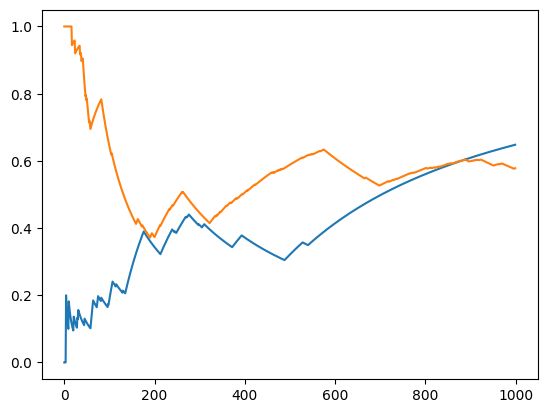

In [ ]:
n_actions  = 10
actions    = np.arange(n_actions)
time_steps = 1000
q_star     = np.random.randn(n_actions)
alpha      = 0.2

epsilon    = 0.1
q_mode     = 'realistic'

_, optimal_action_history_real_eps_greedy = single_bandit(actions, q_star, alpha, epsilon, time_steps, q_mode)

epsilon    = 0.0
q_mode     = 'optimistic'
_, optimal_action_history_optim_greedy = single_bandit(actions, q_star, alpha, epsilon, time_steps, q_mode)

import matplotlib.pyplot as plt
plt.plot(np.cumsum(optimal_action_history_optim_greedy) / (np.arange(len(optimal_action_history_optim_greedy))+1))
plt.plot(np.cumsum(optimal_action_history_real_eps_greedy) / (np.arange(len(optimal_action_history_real_eps_greedy))+1))

# 2.7 Upper-Confidence-Bound Action Selection

## Goal

Among non-greedy actions we need some way to select actions according to their potential for actually being optimal.

## Math

Taking into account both how close their estiamates are to being maximal and the uncertainties in those estimates.

One effective way of doing this is to select actions according to:

$$ A_t \doteq \underset{a}{arg\,max}\Big[Q_t(a) + c \sqrt{\frac{ln t}{N_t(a)}}\Big]$$

where:

$$ Q_{t+1}(a_{best}) \doteq Q_t(a_{best}) + \frac{1}{N_t(a_{best})}\Big[R_{t+1}-Q_t(a_{best})\Big] $$

* $ln\,t$ is logarithm of t
* $N_t(a)$ denotes the number of times that action $a$ has been selected prior to time t

We need to be awary about one important thing in upper formula our $Q_t(a)$ and $N_t(a)$ are arrays. However, in bottom formula both are scalars. In other words, in top formula we use full array of values of each action. In bottom formula we're using $Q_t$ and $N_t$ for best action. Above formulas are simplified versions to emphesize difference, usually no one does that (unfortunately) so we need to be aware of that.

## Intuition

$\frac{1}{N_t(a)}$ — The fewer times action $a$ has been selected, the larger the exploration bonus. This encourages sampling actions with high uncertainty (lack of information).

$\ln t$ — Grows slowly with time. It ensures that exploration pressure increases only logarithmically, so exploitation gradually dominates while exploration never fully disappears.

$\sqrt{\cdot}$ — Comes from Hoeffding’s inequality. The confidence radius for the empirical mean scales as $\sqrt{\frac{\ln t}{N_t(a)}}$, matching the statistical uncertainty of the estimate.


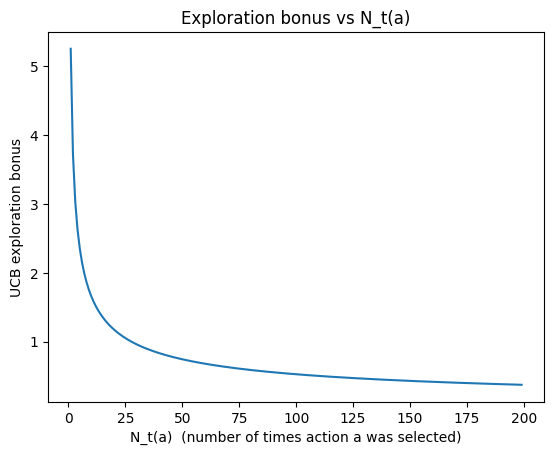

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

c = 2
t = 1000  # fixed time
N = np.arange(1, 200)

bonus = c * np.sqrt(np.log(t) / N)

plt.plot(N, bonus)
plt.xlabel("N_t(a)  (number of times action a was selected)")
plt.ylabel("UCB exploration bonus")
plt.title("Exploration bonus vs N_t(a)")
plt.show()

## Code

In [ ]:
def single_bandit(actions, q_star, time_steps, c):
    # define storages
    action_counts          = {a:0 for a in actions}
    action_value_estimates = {a:0 for a in actions}
    action_history_cnt     = {a:0 for a in actions}

    reward_history         = np.zeros(time_steps)
    optimal_action_history = np.zeros(time_steps)

    # store optimal action
    optimal_action = np.argmax(q_star)

    for t in range(time_steps):

      # we divide by counts so every action needs to be picked at least 1 before using upper bound confidence
      if t < len(actions):
        best_idx = t
      else:
        # upper confidence bound action
        action_value_estimates__vals = np.array(list(action_value_estimates.values()))
        action_history_cnt__vals     = np.array(list(action_history_cnt.values()))

        best_idx = np.argmax(
            action_value_estimates__vals +
            c * np.sqrt(np.log(t) / action_history_cnt__vals)
        )

      # pick best action based on best idx
      a_t                          = actions[best_idx]

      # incerement action count
      action_history_cnt[a_t]     += 1

      # update reward with noise
      reward                       = q_star[a_t] + np.random.randn()

      # update q (formula)
      action_value_estimates[a_t] += (1 / action_history_cnt[a_t]) * (reward - action_value_estimates[a_t])

      # update histories
      reward_history[t]            = reward
      optimal_action_history[t]    = a_t == optimal_action

    return reward_history, optimal_action_history

### Function

In [ ]:
def single_bandit_ucb(actions, time_steps, c, true_q):

  # action values, lets call it estimated q
  estimated_q           = {a:0 for a in actions}
  action_history_counts = {a:0 for a in actions}

  # standard histories
  reward_history         = np.zeros(time_steps)
  optimal_action_history = np.zeros(time_steps)

  # in real world we don't know this set it up only to conduct a test and see if the model picks best action. We know which one is that and model doesn't.
  optimal_action = actions[np.argmax(list(true_q.values()))]

  for t in range(time_steps):
    if t < len(actions):
      best_action_idx = t
    else:
      # We need store Qt(a) and Nt(a) which are specific values of actions (historical count and action value)
      action_history_counts__values = np.array(list(action_history_counts.values()))
      estimated_q__values           = np.array(list(estimated_q.values()))
      # main UCB formula
      best_action_idx = np.argmax(
          estimated_q__values + c * np.sqrt(
              np.log(t) / action_history_counts__values
          )
      )

    # pick best action
    best_action = actions[best_action_idx]

    # add 1 to actions history count
    action_history_counts[best_action] += 1

    # pick reward with some noise - we do that because we don't want to tell model exact actual reward, we want it to infer the underlying true value of action
    reward = true_q[best_action] + np.random.randn()

    # update estimated_q
    estimated_q[best_action] += (1 / action_history_counts[best_action]) * (reward - estimated_q[best_action])

    # update histories
    reward_history[t] = reward
    optimal_action_history[t] = best_action == optimal_action

    # logs
    if t%10 == 0:
      print(f'TIME_STEP: {t} | BEST ACTION: {best_action} | OPTIMAL ACTION: {best_action == optimal_action} | REWARD: {reward:.2f}')

  return reward_history, optimal_action_history, estimated_q

### Environment

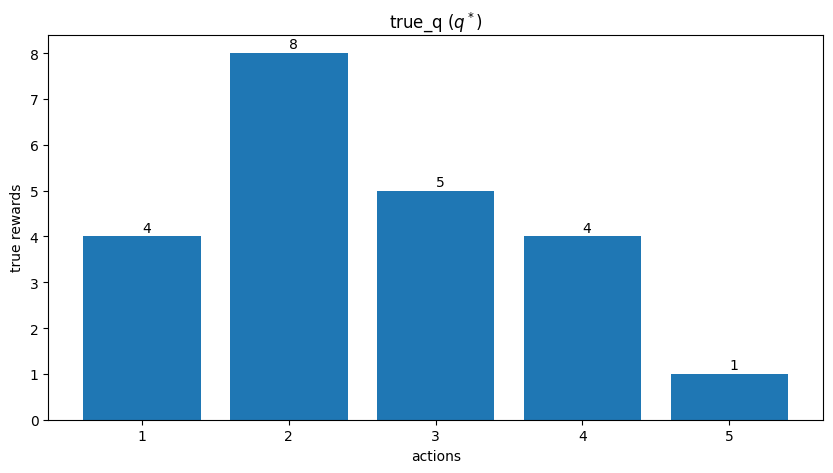

In [ ]:
actions = [1,2,3,4,5]
time_steps = 1000
c = 0.1
true_q = {a:q for a, q in zip(actions, np.random.randint(1, 10, len(actions)))}

plt.figure(figsize = (10,5))
plt.bar(actions, true_q.values())
plt.xlabel('actions')
plt.ylabel('true rewards')
for i, a in enumerate(true_q.values()):
  plt.text(i+1,a+0.1,a)
plt.title('true_q ($q^*$)')
plt.show()

### Run

In [ ]:
reward_history, optimal_action_history, estimated_q = single_bandit_ucb(actions, time_steps, c, true_q)

TIME_STEP: 0 | BEST ACTION: 1 | OPTIMAL ACTION: False | REWARD: 2.65
TIME_STEP: 10 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 8.88
TIME_STEP: 20 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 9.60
TIME_STEP: 30 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 9.58
TIME_STEP: 40 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 8.29
TIME_STEP: 50 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 7.20
TIME_STEP: 60 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 7.19
TIME_STEP: 70 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 11.08
TIME_STEP: 80 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 7.80
TIME_STEP: 90 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 5.40
TIME_STEP: 100 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 8.33
TIME_STEP: 110 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 8.91
TIME_STEP: 120 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 8.12
TIME_STEP: 130 | BEST ACTION: 2 | OPTIMAL ACTION: True | REWARD: 9.14
TIME_STEP: 140 | BEST ACTION:

### Outcomes

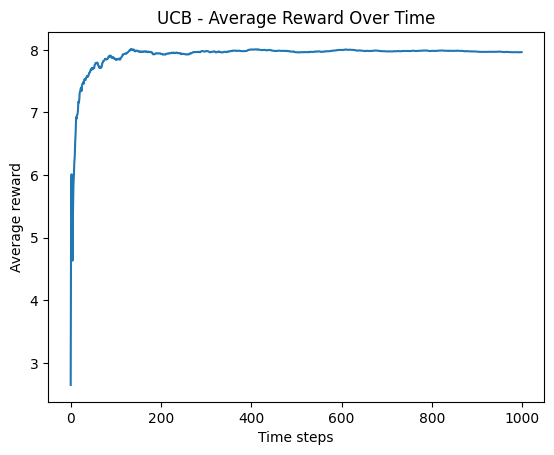

In [ ]:
import matplotlib.pyplot as plt

avg_reward = np.cumsum(reward_history) / np.arange(1, len(reward_history)+1)

plt.plot(avg_reward)
plt.xlabel("Time steps")
plt.ylabel("Average reward")
plt.title("UCB - Average Reward Over Time")
plt.show()

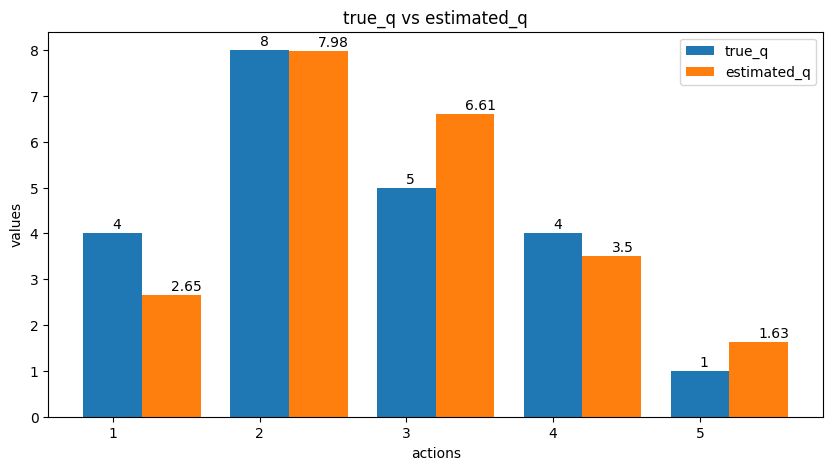

In [ ]:
plt.figure(figsize=(10,5))

labels = list(true_q.keys())
true_vals = [true_q[a] for a in labels]
est_vals  = [estimated_q[a] for a in labels]

plt.bar(labels, true_vals, width=0.4, label='true_q')
plt.bar([a+0.4 for a in labels], est_vals, width=0.4, label='estimated_q')

plt.xlabel('actions')
plt.ylabel('values')

for i, v in enumerate(true_vals):
    plt.text(labels[i], v+0.1, v)

for i, v in enumerate(est_vals):
    plt.text(labels[i]+0.4, v+0.1, round(v,2))

plt.title('true_q vs estimated_q')
plt.legend()
plt.show()

### Experiment

In [ ]:
def single_bandit(actions, q_star, c, epsilon, T, mode):
    N = {a: 0 for a in actions}
    Q = {a: 0.0 for a in actions}

    rewards = np.zeros(T)
    optimal = np.zeros(T)

    a_star = np.argmax(q_star)

    for t in range(T):

        if mode == "eps":
            if np.random.rand() < epsilon:
                a = np.random.choice(actions)
            else:
                a = max(Q, key=Q.get)

        elif mode == "ucb":
            if t < len(actions):
                a = actions[t]  # force each action once
            else:
                a = max(actions, key=lambda a: Q[a] + c * np.sqrt(np.log(t) / N[a]))

        r = q_star[a] + np.random.randn()
        N[a] += 1

        # sample-average update (book setting)
        Q[a] += (r - Q[a]) / N[a]

        rewards[t] = r
        optimal[t] = (a == a_star)

    return rewards, optimal


In [ ]:
import numpy as np

n_actions = 10
actions   = np.arange(n_actions)
T         = 10000
q_star    = np.random.randn(n_actions)

epsilon = 0.1
c       = 2

rewards_eps, optimal_eps = single_bandit(
    actions=actions,
    q_star=q_star,
    c=None,
    epsilon=epsilon,
    T=T,
    mode="eps"
)

rewards_ucb, optimal_ucb = single_bandit(
    actions=actions,
    q_star=q_star,
    c=c,
    epsilon=None,
    T=T,
    mode="ucb"
)


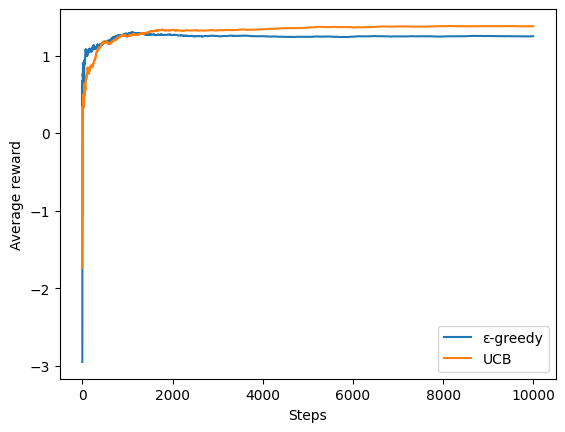

In [ ]:
import matplotlib.pyplot as plt

plt.plot(np.cumsum(rewards_eps) / (np.arange(T) + 1), label="ε-greedy")
plt.plot(np.cumsum(rewards_ucb) / (np.arange(T) + 1), label="UCB")

plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.legend()
# plt.ylim([0,1])
plt.show()

UCB wins on a long run with epsilon-greedy.

# 2.8 Gradient Bandit Algorithms

## Goal

Instead of estimating action values and use those estimates to select actions we're going to consider learning a numerical preference for each action $a$, which we denote $H_t(a)$.

**The higher actions preference, the more often that action is taken**

We use softmax function to define how action is good in comparison to other actions.

## Intuition

The beauty of softmax function is that it's not enough for the action to have high value, softmax pushes towards confidence. That means, softmax is highest if one action has high value and all others actions are 0's. Softmax promotes confidence in choice, not only the choice.

We just need to remember that this is not about rewards, it's called preference.

In [ ]:
import numpy as np

def softmax(x):
    x = np.array(x)
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

In [ ]:
a = [1, 1, 1]
softmax(a)

array([0.33333333, 0.33333333, 0.33333333])

In [ ]:
b = [0.5,0.5,2.0]
softmax(b)

array([0.15428077, 0.15428077, 0.69143845])

In [ ]:
c = [0,0,3]
softmax(c)

array([0.0452785, 0.0452785, 0.909443 ])

As we can see softmax returns the higher probability, the more confident model is about highest value. Thats exactly how here we pick preference of the action, model needs to be confident about it as much as its possible.

In other words softmax returns probabilities the higher the higher difference is between given $a$ and other $a$'s

## Math

$$ Pr{A_t = a} = \frac{e^{H_t(a)}}{\sum_{b=1}^k e^{H_t(b)}} = \pi_t(a)$$

Here we introduce policy, which is basically some function of selecting $a$, here it's softmax function.

On each step, after selecting action $A_t$ and receiving the reward $R_t$ the action preferences are updated by:

$$ H_{t+1}(A_t) = H_t(A_t) + \alpha\,(R_t - \bar{R}_t) (1 - \pi_t(A_t))$$, and

$$H_{t+1}(a) = H_t(a) - \alpha(R_t - \bar{R}_t)\pi_t(a)$$

for all $a\neq A_t$

## Code

**Policy**

---

We define

$$ Pr\{A_t = a\} = \frac{e^{H_t(a)}}{\sum_{i=1}^k e^{H_t(i)}} = \pi_t(a)$$

as

```
exp_H = np.exp(self.H - np.max(self.H))
        return exp_H / exp_H.sum()
```

Where $k$ is number of actions possible.

Subtracting from each action maximum action preference we get much smaller exponent, which make computations way easier.

$$
\frac{e^{H(a)-c}}{\sum_i e^{H(i)-c}}
=
\frac{e^{-c} e^{H(a)}}{e^{-c} \sum_i e^{H(i)}}
=
\frac{e^{H(a)}}{\sum_i e^{H(i)}}
$$

As we see this doesn't change the equation itself and boost performance.

Just to make all very clear: instead H=[1000,999,998] and $e^{1000},e^{999},e^{998}$ which return huge numbers we get H=[0,-1,-2] and $e^{0},e^{-1},e^{-2}$ which is way more digestable by processing unit.

**Action Preferences Update**

---

$$ H_{t+1}(A_t) = H_t(A_t) + \alpha\,(R_t - \bar{R}_t) (1 - \pi_t(A_t))$$, and

$$H_{t+1}(a) = H_t(a) - \alpha(R_t - \bar{R}_t)\pi_t(a)$$

for all $a\neq A_t$

are included in single line of code:

```
self.H += self.alpha * (reward - baseline) * (one_hot - pi)
```

`one_hot` is just a list of 0's and single 1, for selected action. Then naturally, selected action is increased by $1-\pi_t(a)$ and all other actions are deceased by $-\pi_t(a)$.

**Average Reward Update**

---

Here we use traditional formula for iterative reward update, which is based on dynamic programming:

$$
\bar{R}_t = \bar{R}_{t-1} + \frac{1}{t}\left(R_t - \bar{R}_{t-1}\right)
$$

which is expressed in:

```
self.avg_reward += (reward - self.avg_reward) / self.t
```

In [ ]:
import numpy as np

class GradientBandit:
    def __init__(self, k=10, alpha=0.1, baseline=True):
        self.k = k                         # number of actions
        self.alpha = alpha
        self.use_baseline = baseline
        self.H = np.zeros(k, dtype=float)
        self.avg_reward = 0.0
        self.t = 0

    def policy(self):
        exp_H = np.exp(self.H - np.max(self.H))
        return exp_H / exp_H.sum()

    def act(self):
        pi = self.policy()
        return np.random.choice(self.k, p=pi)

    def update(self, action, reward):
        self.t += 1
        baseline = self.avg_reward if self.use_baseline else 0.0

        # Gradient Bandit Update
        pi = self.policy()

        one_hot = np.zeros(self.k)
        one_hot[action] = 1.0

        self.H += self.alpha * (reward - baseline) * (one_hot - pi)

        # Typical Avg Reward update
        if self.use_baseline:
            self.avg_reward += (reward - self.avg_reward) / self.t


np.random.seed(42)
k = 10
true_q = np.random.randn(k) + 4.0
agent = GradientBandit(k=k, alpha=0.1)

steps = 1000

reward_history = np.zeros(steps)
action_history = np.zeros(steps)
optimal_action_history = np.zeros(steps)

for step in range(steps):
    a = agent.act()
    r = np.random.randn() + true_q[a]
    agent.update(a, r)

    action_history[step] = a
    reward_history[step] = r
    optimal_action_history[step] = a == np.argmax(true_q)

print("Final policy:", agent.policy())
print("Best action:", np.argmax(agent.policy()))
print("True best action:", np.argmax(true_q))

Final policy: [1.94465989e-03 1.31031182e-03 3.20027231e-03 9.24775074e-03
 1.04930832e-03 7.55666841e-04 9.78156255e-01 1.73464950e-03
 9.28095577e-04 1.67302974e-03]
Best action: 6
True best action: 6


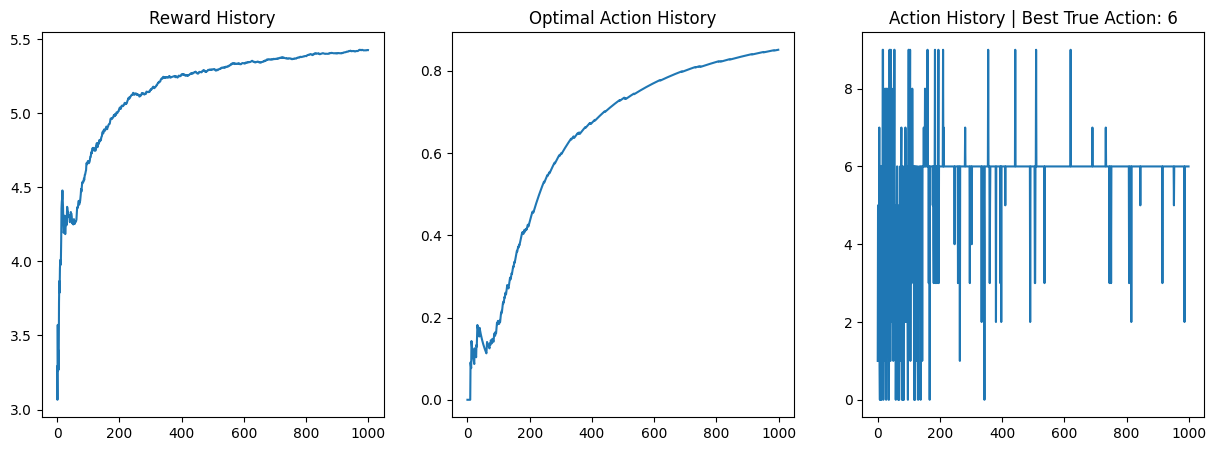

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,3,figsize = (15,5))

axs[0].plot(np.cumsum(reward_history) / np.arange(1, steps + 1), label = 'reward history')
axs[0].set_title('Reward History')

axs[1].plot(np.cumsum(optimal_action_history) / np.arange(1, steps + 1), label = 'optimal action history')
axs[1].set_title('Optimal Action History')

axs[2].plot(action_history)
axs[2].set_title(f'Action History | Best True Action: {np.argmax(true_q)}')
plt.show()

## Experiment

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run(alpha, baseline, steps=1000, k=10):
    true_q = np.random.randn(k) + 4.0
    agent = GradientBandit(k=k, alpha=alpha, baseline=baseline)

    optimal_action_history = np.zeros(steps, dtype=float)
    best_action = np.argmax(true_q)

    for step in range(steps):
        a = agent.act()
        r = np.random.randn() + true_q[a]
        agent.update(a, r)
        optimal_action_history[step] = (a == best_action)

    return optimal_action_history


def average_runs(alpha, baseline, runs=2000, steps=1000, k=10):
    all_histories = np.zeros((runs, steps), dtype=float)

    for run_id in range(runs):
        all_histories[run_id] = run(alpha, baseline, steps, k)

    return all_histories.mean(axis=0)

runs = 2000
steps = 1000

wb01 = np.zeros((runs, steps))
wb04 = np.zeros((runs, steps))
wob01 = np.zeros((runs, steps))
wob04 = np.zeros((runs, steps))

for i in range(runs):
    wb01[i] = run(alpha=0.1, baseline=True)
    wb04[i] = run(alpha=0.4, baseline=True)
    wob01[i] = run(alpha=0.1, baseline=False)
    wob04[i] = run(alpha=0.4, baseline=False)

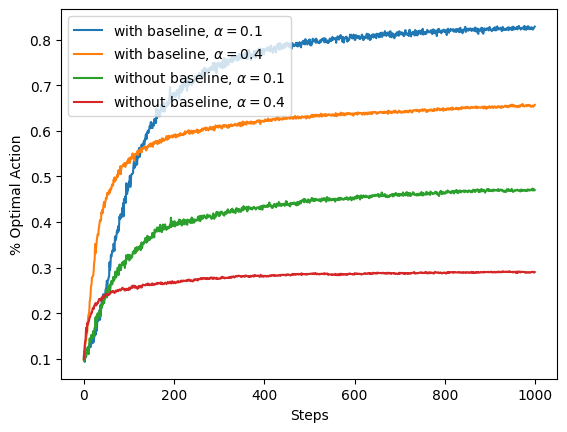

In [ ]:
plt.plot(wb01.mean(axis=0), label=r'with baseline, $\alpha=0.1$')
plt.plot(wb04.mean(axis=0), label=r'with baseline, $\alpha=0.4$')
plt.plot(wob01.mean(axis=0), label=r'without baseline, $\alpha=0.1$')
plt.plot(wob04.mean(axis=0), label=r'without baseline, $\alpha=0.4$')
plt.ylabel('% Optimal Action')
plt.xlabel('Steps')
plt.legend()
plt.show()

# 2.9 Associative Search (Contextual Bandits)

## Intuition

Associative = you get a context/signal before acting.

Example:

Rainy day → umbrella is best
Sunny day → sunglasses are best

If you cannot see the weather, you choose one average-best item.

If you can see the weather, you condition your action:

rainy→umbrella
sunny→sunglasses

In this bandit:

A→a
2
	​

B→a
1
	​


So associative search is basically:

learn the best action per situation, not one best action globally.

Associative task is not mainly about switching between stationary and non-stationary settings. It is about learning a mapping from context (state) to action, so the policy must change depending on the situation the agent observes. In other words, the agent does not use one global preference for actions, but a conditional policy: one action may be best in one context, while another is best in a different context.

Let's review it on an example.

Suppose you face a 2-armed bandit task whose true action values change
randomly from time step to time step. Specifically, suppose that, for any time step,
the true values of actions 1 and 2 are respectively 10 and 20 with probability 0.5 (case
A), and 90 and 80 with probability 0.5 (case B). If you are not able to tell which case
you face at any step, what is the best expected reward you can achieve and how should
you behave to achieve it? Now suppose that on each step you are told whether you are
facing case A or case B (although you still don’t know the true action values). This is an
associative search task. What is the best expected reward you can achieve in this task,
and how should you behave to achieve it?

If we are not able to tell which case we face at any step, best expected reward is 85, to achieve it we should always pick bandit B.

**Non-associative** tasks assume 1 actions behaviour, in our example:

* Bandit 1:
  * Action 1: 10
  * Action 2: 20

* Bandit 2:
  * Action 1: 90
  * Action 2: 80

Since we don't know which bandit we're facing we count Expected Value as usual:

$$ P = 0.5 \times 10 + 0.5 \times 90 = 50 $$
$$ P = 0.5 \times 20 + 0.5 \times 80 = 50 $$

In both cases we have 50.

It's important to note that in Bandit A Action 1 is worse out of 2, and in Bandit B Action 1 is better out of 2. Due to that, we don't know whether we want to pick Action 1 or Action 2, that depends on which Bandit we're facing but this we don't know in Non-associative setup.

In **Associative** task we are told which Bandit we're going to spin. We can simply pick Action 1 when it's Bandit 1, and pick Action 2 when it's Bandit 2. That's the simplest possible policy. In such case our Expected value will become:

$$ P = 0.5 \times 20 + 0.5 \times 90 = 55 $$

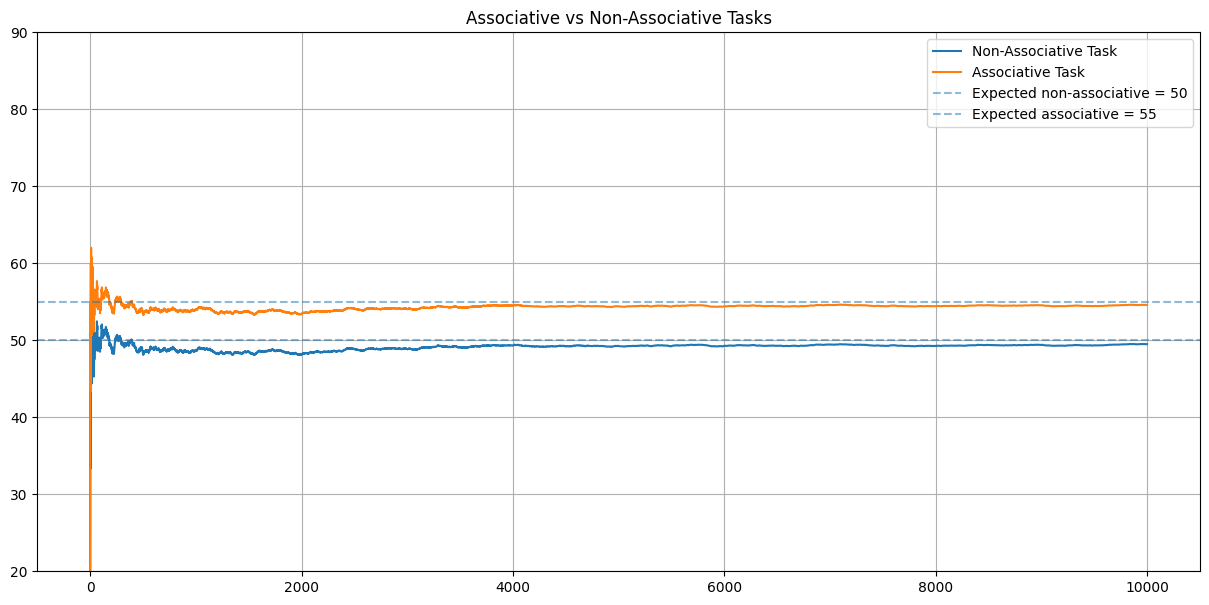

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

non_associative_tasks = []
associative_tasks     = []

T = 10000

for i in range(T):

    case = np.random.choice(['A', 'B'])

    if case == "A":
      values = [10, 20]
    else:
      values = [90, 80]

    # Non-Associative task - we pick action randomly
    action = np.random.randn() > .5
    non_associative_tasks.append(values[action])

    # Associative task - if Bandit A we pick action 2 if Bandit B we pick action 1

    if case == "A":
      action = 1
    else:
      action = 0

    associative_tasks.append(values[action])


plt.figure(figsize = (15, 7))
plt.plot(np.cumsum(non_associative_tasks) / np.arange(1, T + 1), label = 'Non-Associative Task')
plt.plot(np.cumsum(associative_tasks) / np.arange(1, T + 1), label = 'Associative Task')
plt.axhline(50, linestyle="--", label="Expected non-associative = 50", alpha = .5)
plt.axhline(55, linestyle="--", label="Expected associative = 55", alpha = .5)
plt.ylim([20,90])
plt.title('Associative vs Non-Associative Tasks')
plt.legend()
plt.grid()
plt.show()

# Exercises

## 2.2

In [ ]:
k               = np.arange(1,5)
q_star          = np.zeros(len(k))
actions_history = [1,2,2,2,3]
rewards_history = [-1,1,-2,2,0]

print('k:',k)
print('q_star:',q_star)
print('initial action_history:', actions_history)
print('initial rewards_history:', rewards_history)

k: [1 2 3 4]
q_star: [0. 0. 0. 0.]
initial action_history: [1, 2, 2, 2, 3]
initial rewards_history: [-1, 1, -2, 2, 0]


In [ ]:
Q = q_star.copy()
counts = {a: 0 for a in k}

for t, (a, r) in enumerate(zip(actions_history, rewards_history), start=1):
    counts[a] += 1
    Q[a-1] += (r - Q[a-1]) / counts[a]

    means = ", ".join([f"a{ai}: {Q[ai-1]:.2f}" for ai in k])
    print(f"t={t:2d} | action={a:2d} | reward={r:3d} | mean_rewards = [{means}]")

t= 1 | action= 1 | reward= -1 | mean_rewards = [a1: -1.00, a2: 0.00, a3: 0.00, a4: 0.00]
t= 2 | action= 2 | reward=  1 | mean_rewards = [a1: -1.00, a2: 1.00, a3: 0.00, a4: 0.00]
t= 3 | action= 2 | reward= -2 | mean_rewards = [a1: -1.00, a2: -0.50, a3: 0.00, a4: 0.00]
t= 4 | action= 2 | reward=  2 | mean_rewards = [a1: -1.00, a2: 0.33, a3: 0.00, a4: 0.00]
t= 5 | action= 3 | reward=  0 | mean_rewards = [a1: -1.00, a2: 0.33, a3: 0.00, a4: 0.00]


Random:

A1 – we don't have maximal value, since $Q_1(a)=0$ for all $a$, i.e. either random or tie-break with argmax.

A2 – $R_1$ is negative, so there are multiple actions with the highest reward estimate, i.e. we could go random or tie-break with greedy pick.

A3 – greedy, since $A_2 = 2$ had reward $R_2 = 1$, so $Q(2)=1$ is the highest reward estimate and we pick again $A_3 = 2$.

A4 – we again get $A_4 = 2$, but this time it had to be random, since action $2$ has mean reward
$$
Q(2) = \frac{1 - 2}{2} = -0.5
$$
which is lower than $0$, i.e. we have other actions that are higher than action $2$.

A5 – again we do random, previously for action $2$ we got reward $R_4 = 2$, now action $2$ has mean reward
$$
Q(2) = \frac{1 - 2 + 2}{3} = \frac{1}{3}
$$
which is the highest mean reward of all actions, but the model picks action $3$, which needs to be random.


## 2.3

In the long run, best is $\epsilon = 0.01$. It converges more slowly but its ceil is higher.

In [ ]:
import numpy as np

def single_bandit(actions, q_star, epsilon, time_steps):
  action_counts       = {a:0 for a in actions}
  action_reward_means = {a:0 for a in actions}

  reward_over_time         = np.zeros(time_steps)
  optimal_action_over_time = np.zeros(time_steps)

  optimal_action = np.argmax(q_star)

  for t in range(time_steps):
    if np.random.rand() <= epsilon:
      a_t = np.random.choice(actions)
    else:
      a_t = max(actions, key = lambda a: action_reward_means[a])

    action_counts[a_t]       += 1
    reward                    = q_star[a_t] + np.random.randn()
    action_reward_means[a_t] += (reward - action_reward_means[a_t]) / action_counts[a_t]

    reward_over_time[t]         = reward
    optimal_action_over_time[t] = a_t == optimal_action

  return reward_over_time, optimal_action_over_time

In [ ]:
n_actions = 10
actions   = np.arange(n_actions)
q_star = np.random.randn(n_actions)
epsilon = 0.01
time_steps = 10000

reward_over_time, optimal_action_over_time = single_bandit(actions, q_star, epsilon, time_steps)

In [ ]:
len(reward_over_time), len(optimal_action_over_time)

(10000, 10000)

## 2.5

In [ ]:
import numpy as np

def single_bandit(actions, epsilon, alpha, q_star, time_step):

  action_count = {a: 0 for a in actions}
  action_value_estimate = {a: 0 for a in actions}

  reward_history = np.zeros(time_step)
  optimal_action_history = np.zeros(time_step)


  for t in range(time_step):
    q_star += np.random.normal(0,0.01,size=len(actions))
    optimal_action = np.argmax(q_star)                                                        # non stationary problem picks optimal_action on fly

    if np.random.rand() <= epsilon:
      a_t = np.random.choice(actions)
    else:
      best = max(action_value_estimate.values())
      choices = [a for a, v in action_value_estimate.items() if v == best]
      a_t = np.random.choice(choices)

    action_count[a_t] += 1
    reward = q_star[a_t] + np.random.randn()
    if alpha:
      action_value_estimate[a_t] += (reward - action_value_estimate[a_t]) * alpha              # we do const step-size
    else:
      action_value_estimate[a_t] += (reward - action_value_estimate[a_t]) / action_count[a_t]  # we do sample-average

    reward_history[t] = reward
    optimal_action_history[t] = a_t == optimal_action

  return reward_history, optimal_action_history

In [ ]:
n_actions = 10
actions = np.arange(n_actions)
epsilon = 0.1
alpha = 0.2
q_star = np.zeros(10)
time_step = 10000

sample_avg_reward_history, sample_avg_optimal_action_history = single_bandit(actions=actions, epsilon=epsilon, alpha=False, q_star=q_star, time_step=time_step)
const_step_reward_history, const_step_optimal_action_history = single_bandit(actions=actions, epsilon=epsilon, alpha=0.1,   q_star=q_star, time_step=time_step)

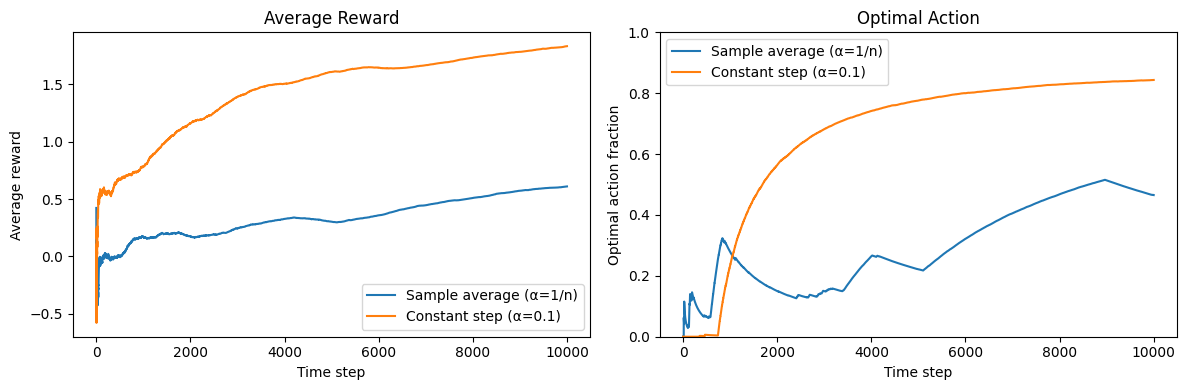

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ===== Average reward =====
avg_reward_sample = np.cumsum(sample_avg_reward_history) / (
    np.arange(len(sample_avg_reward_history)) + 1
)
avg_reward_const = np.cumsum(const_step_reward_history) / (
    np.arange(len(const_step_reward_history)) + 1
)

axes[0].plot(avg_reward_sample, label="Sample average (α=1/n)")
axes[0].plot(avg_reward_const, label="Constant step (α=0.1)")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Average reward")
axes[0].set_title("Average Reward")
axes[0].legend()

# ===== Optimal action fraction =====
opt_frac_sample = np.cumsum(sample_avg_optimal_action_history) / (
    np.arange(len(sample_avg_optimal_action_history)) + 1
)
opt_frac_const = np.cumsum(const_step_optimal_action_history) / (
    np.arange(len(const_step_optimal_action_history)) + 1
)

axes[1].plot(opt_frac_sample, label="Sample average (α=1/n)")
axes[1].plot(opt_frac_const, label="Constant step (α=0.1)")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Optimal action fraction")
axes[1].set_title("Optimal Action")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

We can see a huge advantage of the constant step over the sample average in a nonstationary problem. The average reward is low for the sample-average method due to the lack of adaptation to the changing environment. The optimal action plot, on the other hand, shows a loss of control over the optimal action.